# 08. Task, Wrist & Symmetry Analysis

This notebook analyzes wearable sensor features extracted from the PADS dataset to understand movement characteristics across different motor tasks and wrist locations.

The objectives are to:

- analyze task-specific wearable feature characteristics across motor activities;
- evaluate wrist-specific feature distributions between LeftWrist and RightWrist recordings;
- compare wearable sensor measurements between left and right wrist locations;
- investigate left-right wrist symmetry and asymmetry patterns using paired recordings;
- analyze accelerometer and gyroscope-based movement features;
- standardize wearable feature descriptions and create a feature dictionary for interpretation;
- generate summary features that can support downstream exploratory analysis and machine learning modelling.

## 1. Import Libraries

In [7]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

## 2. Define Project Paths

In [8]:
PROJECT_ROOT = Path("..").resolve()

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR = OUTPUT_DIR / "figures"


if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [9]:
# Select representative wearable features for wrist comparison

selected_wrist_features = [
    "Accelerometer_X_Mean",
    "Accelerometer_X_RMS",
    "Gyroscope_X_Mean",
    "Gyroscope_X_RMS",
    "Gyro_Magnitude_Energy",
    "Acc_Magnitude_Energy"
]

# Calculate mean feature values by wrist

wrist_feature_means = (
    task_wrist_df
    .groupby("wrist")[selected_wrist_features]
    .mean()
)


## 3. Load Feature Tables

In [10]:
TIME_FEATURE_FILE = (
    TABLES_DIR / "time_domain_features.csv"
)

task_wrist_df = pd.read_csv(
    TIME_FEATURE_FILE,
    dtype={"patient_id": str}
)

print("Dataset shape:", task_wrist_df.shape)

display(task_wrist_df.head())

Dataset shape: (10318, 77)


,patient_id,task,wrist,recording_Key,source_File,Accelerometer_X_Mean,Accelerometer_X_Median,Accelerometer_X_Std,Accelerometer_X_Min,Accelerometer_X_Max,...,Acc_Magnitude_Energy,Gyro_Magnitude_Mean,Gyro_Magnitude_Median,Gyro_Magnitude_Std,Gyro_Magnitude_Min,Gyro_Magnitude_Max,Gyro_Magnitude_Range,Gyro_Magnitude_IQR,Gyro_Magnitude_RMS,Gyro_Magnitude_Energy
0,001,CrossArms,LeftWrist,CrossArms__LeftWrist,001_preprocessed.npz,-0.000278,-0.000864,0.086120,-0.405191,0.395058,...,34.294886,1.101626,0.036279,1.931856,0.001287,7.555477,7.554190,1.230665,2.223021,4823.219233
1,001,CrossArms,RightWrist,CrossArms__RightWrist,001_preprocessed.npz,0.000139,-0.000414,0.076206,-0.287730,0.344297,...,26.557016,1.022689,0.038048,1.810530,0.002150,7.615600,7.613449,1.020145,2.078594,4216.858971
2,001,DrinkGlas,LeftWrist,DrinkGlas__LeftWrist,001_preprocessed.npz,0.000321,0.002782,0.063836,-0.212264,0.528248,...,22.423766,0.836871,0.522552,1.022789,0.002307,10.018781,10.016473,1.260728,1.321128,1703.490553
3,001,DrinkGlas,RightWrist,DrinkGlas__RightWrist,001_preprocessed.npz,0.000390,0.000479,0.114052,-0.471591,0.464202,...,54.840312,1.910277,1.134303,2.402229,0.005604,14.187778,14.182174,1.842655,3.068216,9188.015675
4,001,Entrainment,LeftWrist,Entrainment__LeftWrist,001_preprocessed.npz,0.000133,0.001578,0.019979,-0.078619,0.126308,...,4.779990,0.080700,0.068932,0.051170,0.005157,0.369170,0.364013,0.058443,0.095549,18.259263


## 4. Task-Specific Feature Analysis

In [11]:
print("Unique tasks:")
print(task_wrist_df["task"].unique())

print("\nNumber of tasks:", task_wrist_df["task"].nunique())

Unique tasks:
<StringArray>
[  'CrossArms',   'DrinkGlas', 'Entrainment',  'HoldWeight',    'LiftHold',
 'PointFinger', 'RelaxedTask',     'Relaxed', 'StretchHold',  'TouchIndex',
   'TouchNose']
Length: 11, dtype: str

Number of tasks: 11


In [12]:
task_summary = (
    task_wrist_df
    .groupby("task")
    .agg(
        Recordings=("patient_id", "count"),
        Participants=("patient_id", "nunique")
    )
)

display(task_summary)

,Recordings,Participants
task,,
CrossArms,938,469
DrinkGlas,938,469
Entrainment,938,469
HoldWeight,938,469
LiftHold,938,469
PointFinger,938,469
Relaxed,938,469
RelaxedTask,938,469
StretchHold,938,469


### Task Feature Comparison

Representative wearable sensor features were compared across motor tasks to examine differences in movement characteristics between activities.

In [13]:
task_feature_summary = (
    task_wrist_df
    .groupby("task")[selected_wrist_features]
    .mean()
)

display(task_feature_summary)

,Accelerometer_X_Mean,Accelerometer_X_RMS,Gyroscope_X_Mean,Gyroscope_X_RMS,Gyro_Magnitude_Energy,Acc_Magnitude_Energy
task,,,,,,
CrossArms,-0.000008,0.037189,-0.001825,0.351805,889.303132,14.950311
DrinkGlas,-0.000091,0.051461,0.022996,0.671595,1050.961596,21.827298
Entrainment,-0.000019,0.042330,0.001087,0.193332,431.589123,25.141065
HoldWeight,-0.000047,0.011092,0.000598,0.104510,71.598039,2.814748
LiftHold,-0.000035,0.017474,0.029238,0.186068,170.452275,3.370827
PointFinger,-0.000065,0.127213,-0.000007,0.737260,3197.325513,108.719383
Relaxed,-0.000009,0.009043,0.000046,0.078160,229.855196,8.289965
RelaxedTask,-0.000012,0.012779,-0.000205,0.122178,463.783987,19.096148
StretchHold,-0.000015,0.010222,0.002800,0.083153,65.040813,2.842895


### Recordings per Motor Task

Each motor task contains recordings from both the left and right wrist for all participants. 
The distribution is balanced across tasks, with 938 recordings available for each motor activity.

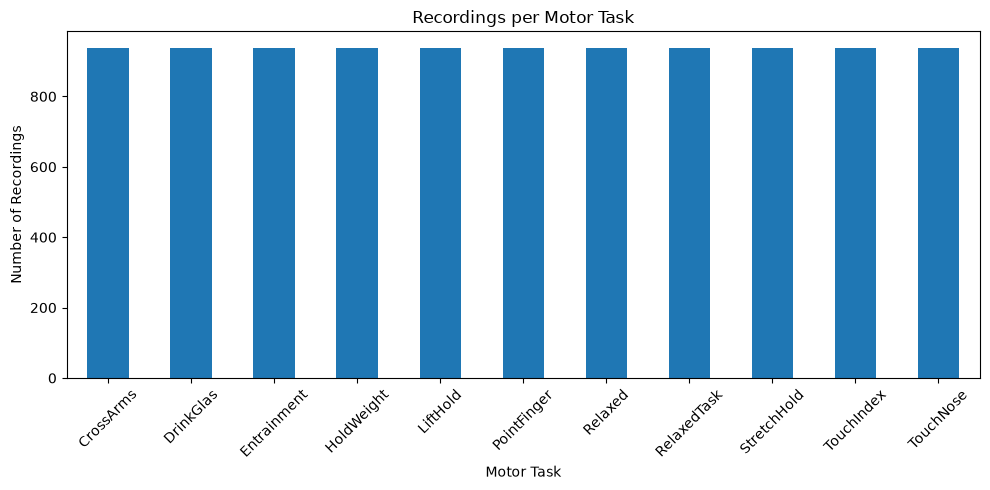

In [14]:

# Recordings per Motor Task

plt.figure(figsize=(10, 5))

task_summary["Recordings"].plot(kind="bar")

plt.title("Recordings per Motor Task")
plt.xlabel("Motor Task")
plt.ylabel("Number of Recordings")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 5. Wrist-Specific Feature Analysis

In [15]:
# Summarize recordings by wrist location

wrist_summary = (
    task_wrist_df
    .groupby("wrist")
    .agg(
        Recordings=("patient_id", "count"),
        Participants=("patient_id", "nunique"),
        Tasks=("task", "nunique")
    )
    .sort_values("Recordings", ascending=False)
)

display(wrist_summary)

,Recordings,Participants,Tasks
wrist,,,
LeftWrist,5159,469,11
RightWrist,5159,469,11


### Wrist Distribution Analysis

The PADS dataset contains wearable sensor recordings from two wrist locations: LeftWrist and RightWrist. This analysis summarizes the number of recordings, participants, and motor tasks available for each wrist location.

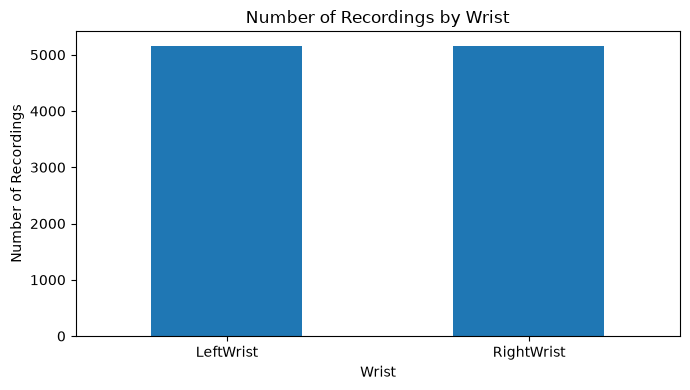

In [16]:

# Recordings by Wrist

plt.figure(figsize=(7, 4))

wrist_summary["Recordings"].plot(kind="bar")

plt.title("Number of Recordings by Wrist")
plt.xlabel("Wrist")
plt.ylabel("Number of Recordings")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Wrist Recording Distribution

The dataset contains wearable sensor recordings from both the LeftWrist and RightWrist locations. The number of recordings is balanced between the two wrists, indicating equal representation of both sensor locations for subsequent feature analysis.

## 6. Left vs Right Wrist Comparison

In [17]:
# Select representative wearable features for wrist comparison

selected_wrist_features = [
    "Accelerometer_X_Mean",
    "Accelerometer_X_RMS",
    "Gyroscope_X_Mean",
    "Gyroscope_X_RMS",
    "Gyro_Magnitude_Energy",
    "Acc_Magnitude_Energy"
]

# Calculate mean feature values by wrist

wrist_feature_means = (
    task_wrist_df
    .groupby("wrist")[selected_wrist_features]
    .mean()
)

display(wrist_feature_means)

,Accelerometer_X_Mean,Accelerometer_X_RMS,Gyroscope_X_Mean,Gyroscope_X_RMS,Gyro_Magnitude_Energy,Acc_Magnitude_Energy
wrist,,,,,,
LeftWrist,-0.000005,0.052276,0.000731,0.478272,2308.528204,35.900104
RightWrist,-0.000078,0.050318,0.003528,0.476362,2276.644678,35.451210


### Average Feature Comparison Between Wrists

The average wearable sensor features were compared between LeftWrist and RightWrist recordings. This analysis examines whether movement characteristics show similar patterns across wrist locations or whether differences exist between the two sides.

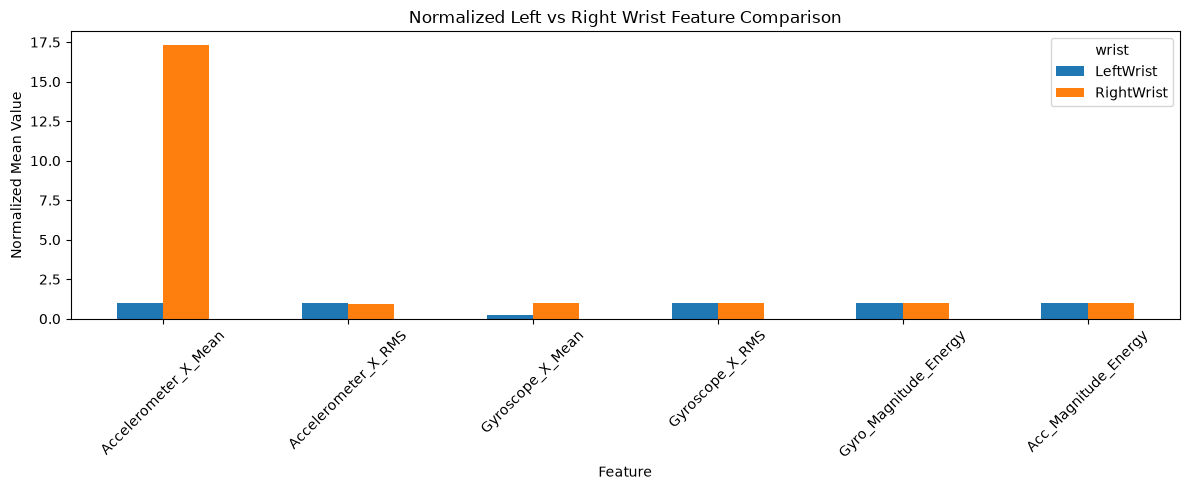

In [18]:
# Normalize wrist feature comparison for visualization

wrist_feature_normalized = (
    wrist_feature_means /
    wrist_feature_means.max()
)

(
    wrist_feature_normalized.T
    .plot(
        kind="bar",
        figsize=(12,5)
    )
)

plt.title("Normalized Left vs Right Wrist Feature Comparison")
plt.xlabel("Feature")
plt.ylabel("Normalized Mean Value")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Left vs Right Wrist Feature Comparison

The mean values of selected wearable sensor features were compared between LeftWrist and RightWrist recordings. The feature distributions show similar patterns across both wrist locations, allowing differences in movement characteristics between the two sides to be examined.

## 7. Symmetry Analysis

In [19]:
# Separate left and right wrist recordings

left_wrist = (
    task_wrist_df[
        task_wrist_df["wrist"] == "LeftWrist"
    ]
    .copy()
)

right_wrist = (
    task_wrist_df[
        task_wrist_df["wrist"] == "RightWrist"
    ]
    .copy()
)

print("Left wrist recordings:", len(left_wrist))
print("Right wrist recordings:", len(right_wrist))

Left wrist recordings: 5159
Right wrist recordings: 5159


In [20]:
# Merge Left and Right Wrist Recordings

symmetry_df = left_wrist.merge(
    right_wrist,
    on=["patient_id", "task"],
    suffixes=("_left", "_right")
)

print("Paired recordings:", symmetry_df.shape)

display(symmetry_df.head())

Paired recordings: (5159, 152)


,patient_id,task,wrist_left,recording_Key_left,source_File_left,Accelerometer_X_Mean_left,Accelerometer_X_Median_left,Accelerometer_X_Std_left,Accelerometer_X_Min_left,Accelerometer_X_Max_left,...,Acc_Magnitude_Energy_right,Gyro_Magnitude_Mean_right,Gyro_Magnitude_Median_right,Gyro_Magnitude_Std_right,Gyro_Magnitude_Min_right,Gyro_Magnitude_Max_right,Gyro_Magnitude_Range_right,Gyro_Magnitude_IQR_right,Gyro_Magnitude_RMS_right,Gyro_Magnitude_Energy_right
0,001,CrossArms,LeftWrist,CrossArms__LeftWrist,001_preprocessed.npz,-0.000278,-0.000864,0.086120,-0.405191,0.395058,...,26.557016,1.022689,0.038048,1.810530,0.002150,7.615600,7.613449,1.020145,2.078594,4216.858971
1,001,DrinkGlas,LeftWrist,DrinkGlas__LeftWrist,001_preprocessed.npz,0.000321,0.002782,0.063836,-0.212264,0.528248,...,54.840312,1.910277,1.134303,2.402229,0.005604,14.187778,14.182174,1.842655,3.068216,9188.015675
2,001,Entrainment,LeftWrist,Entrainment__LeftWrist,001_preprocessed.npz,0.000133,0.001578,0.019979,-0.078619,0.126308,...,5.780458,0.097082,0.083818,0.059865,0.005369,0.426621,0.421252,0.064613,0.114048,26.013994
3,001,HoldWeight,LeftWrist,HoldWeight__LeftWrist,001_preprocessed.npz,0.000143,0.000411,0.003970,-0.015384,0.010517,...,0.071343,0.034579,0.032897,0.016342,0.002344,0.109307,0.106963,0.021306,0.038242,1.427376
4,001,LiftHold,LeftWrist,LiftHold__LeftWrist,001_preprocessed.npz,-0.000554,-0.000604,0.019603,-0.121126,0.069439,...,3.164238,0.253258,0.024614,0.596978,0.001570,3.201658,3.200088,0.034671,0.648196,410.073646


In [21]:
# Calculate Left-Right Wrist Feature Differences

symmetry_features = pd.DataFrame()

symmetry_features["patient_id"] = symmetry_df["patient_id"]
symmetry_features["task"] = symmetry_df["task"]

for feature in selected_wrist_features:
    symmetry_features[f"{feature}_difference"] = (
        symmetry_df[f"{feature}_left"] -
        symmetry_df[f"{feature}_right"]
    )

display(symmetry_features.head())

,patient_id,task,Accelerometer_X_Mean_difference,Accelerometer_X_RMS_difference,Gyroscope_X_Mean_difference,Gyroscope_X_RMS_difference,Gyro_Magnitude_Energy_difference,Acc_Magnitude_Energy_difference
0,001,CrossArms,-0.000416,0.009909,-0.152655,-0.266105,606.360262,7.737870
1,001,DrinkGlas,-0.000070,-0.050190,-0.082635,-1.420895,-7484.525123,-32.416546
2,001,Entrainment,0.000283,-0.001366,0.006499,-0.012581,-7.754731,-1.000469
3,001,HoldWeight,0.000084,0.000243,0.007948,-0.010174,-0.620731,-0.000726
4,001,LiftHold,0.000181,-0.000041,-0.166941,-0.278712,-18.745048,-0.605432


In [22]:
# Average Absolute Wrist Difference by Motor Task

task_asymmetry = symmetry_features.copy()

difference_columns = [
    col for col in task_asymmetry.columns
    if "_difference" in col
]

task_asymmetry[difference_columns] = (
    task_asymmetry[difference_columns]
    .abs()
)

task_asymmetry_summary = (
    task_asymmetry
    .groupby("task")[difference_columns]
    .mean()
)

display(task_asymmetry_summary)

,Accelerometer_X_Mean_difference,Accelerometer_X_RMS_difference,Gyroscope_X_Mean_difference,Gyroscope_X_RMS_difference,Gyro_Magnitude_Energy_difference,Acc_Magnitude_Energy_difference
task,,,,,,
CrossArms,0.001088,0.009594,0.047861,0.130715,329.220394,11.920878
DrinkGlas,0.000993,0.017699,0.056041,0.214592,551.028357,18.504219
Entrainment,0.000298,0.009546,0.007741,0.096059,454.542380,16.899632
HoldWeight,0.000382,0.006967,0.007983,0.076876,89.026250,3.379888
LiftHold,0.000636,0.004392,0.028875,0.076016,85.037126,2.641998
PointFinger,0.001285,0.033148,0.033080,0.244915,1017.124566,43.615856
Relaxed,0.000122,0.006945,0.003022,0.080573,389.117788,11.993635
RelaxedTask,0.000133,0.009152,0.003073,0.117065,660.617996,21.996268
StretchHold,0.000369,0.003668,0.006423,0.053873,70.068675,3.217635


In [23]:
# Overall Wrist Asymmetry Summary

difference_columns = [
    col for col in symmetry_features.columns
    if "difference" in col
]

asymmetry_summary = (
    symmetry_features[difference_columns]
    .abs()
    .mean()
    .sort_values(ascending=False)
)

display(asymmetry_summary.head(10))

Gyro_Magnitude_Energy_difference    730.994984
Acc_Magnitude_Energy_difference      17.668487
Gyroscope_X_RMS_difference            0.160079
Gyroscope_X_Mean_difference           0.030580
Accelerometer_X_RMS_difference        0.013123
Accelerometer_X_Mean_difference       0.000751
dtype: float64

### Wrist Asymmetry Findings

Overall wrist asymmetry was evaluated using paired left-right recordings from the same participant and motor task. Energy-based features exhibited the largest average absolute differences between wrists, while mean and RMS features showed substantially smaller differences. Because energy measurements are naturally larger in numerical scale, these values should be interpreted as larger absolute feature differences rather than stronger physiological asymmetry between the left and right wrists

### Task-Level Asymmetry Analysis

To better understand wrist asymmetry across motor tasks, the average absolute left-right differences were summarized separately for each task using representative wearable sensor features. This provides a task-specific view of wrist asymmetry across different motor activities while avoiding direct comparisons between feature types with substantially different numerical scales.

In [24]:
# Representative features for task-level asymmetry

selected_wrist_features = [
    "Accelerometer_X_Mean",
    "Accelerometer_X_RMS",
    "Gyroscope_X_Mean",
    "Gyroscope_X_RMS",
    "Gyro_Magnitude_Energy",
    "Acc_Magnitude_Energy"
]

# Calculate average absolute wrist differences by task

task_asymmetry = pd.DataFrame()

task_asymmetry["task"] = symmetry_features["task"]

for feature in selected_wrist_features:
    task_asymmetry[feature] = symmetry_features[f"{feature}_difference"].abs()

task_asymmetry_summary = (
    task_asymmetry
    .groupby("task")
    .mean()
)

display(task_asymmetry_summary)

,Accelerometer_X_Mean,Accelerometer_X_RMS,Gyroscope_X_Mean,Gyroscope_X_RMS,Gyro_Magnitude_Energy,Acc_Magnitude_Energy
task,,,,,,
CrossArms,0.001088,0.009594,0.047861,0.130715,329.220394,11.920878
DrinkGlas,0.000993,0.017699,0.056041,0.214592,551.028357,18.504219
Entrainment,0.000298,0.009546,0.007741,0.096059,454.542380,16.899632
HoldWeight,0.000382,0.006967,0.007983,0.076876,89.026250,3.379888
LiftHold,0.000636,0.004392,0.028875,0.076016,85.037126,2.641998
PointFinger,0.001285,0.033148,0.033080,0.244915,1017.124566,43.615856
Relaxed,0.000122,0.006945,0.003022,0.080573,389.117788,11.993635
RelaxedTask,0.000133,0.009152,0.003073,0.117065,660.617996,21.996268
StretchHold,0.000369,0.003668,0.006423,0.053873,70.068675,3.217635


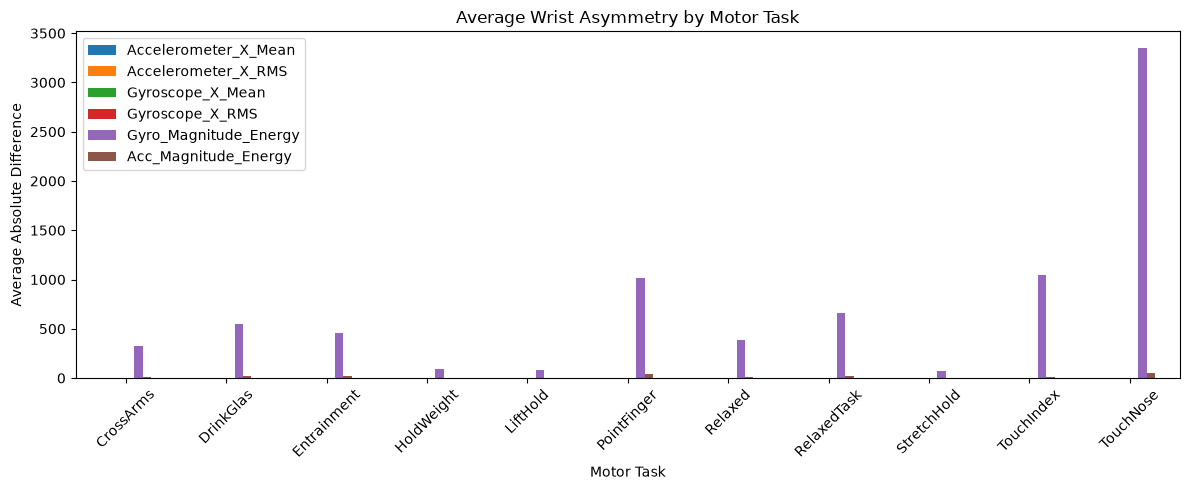

In [25]:
task_asymmetry_summary.plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Average Wrist Asymmetry by Motor Task")
plt.xlabel("Motor Task")
plt.ylabel("Average Absolute Difference")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Task-Level Findings

Average absolute wrist differences were summarized separately for each motor task using representative accelerometer and gyroscope features.Tasks such as TouchNose, TouchIndex, and PointFinger exhibited larger average wrist differences for the selected energy features than static holding tasks such as HoldWeight and StretchHold. These results indicate that movement-intensive tasks produce greater left-right feature differences, suggesting that wrist asymmetry varies according to the type of motor activity being performed. Such task-specific patterns may provide informative wearable features for downstream exploratory analysis and machine learning.

## 8. Wearable Feature Dictionary

The dataset contains time-domain features extracted from smartwatch sensor signals. These features summarize movement characteristics from accelerometer and gyroscope measurements collected from both wrists during different motor tasks.

### 1. Accelerometer Features

Accelerometer features describe linear movement and changes in body motion along the X, Y, and Z axes.

| Feature Type | Description |
|---|---|
| Mean | Average acceleration value during the recording period |
| Median | Middle acceleration value, less affected by extreme movements |
| Standard Deviation (Std) | Measures variability or consistency of movement |
| Minimum (Min) | Lowest recorded acceleration value |
| Maximum (Max) | Highest recorded acceleration value |
| Range | Difference between maximum and minimum acceleration |
| IQR | Measures the spread of the middle 50% of acceleration values |
| RMS | Represents the signal magnitude and overall movement intensity |
| Energy | Represents the total movement intensity within the recording |

### 2. Gyroscope Features

Gyroscope features describe rotational motion captured from wrist sensor signals.

| Feature Type | Description |
|---|---|
| Mean | Average rotational velocity |
| Median | Central rotational movement value |
| Standard Deviation (Std) | Variation in wrist rotation |
| Minimum (Min) | Lowest recorded rotational value |
| Maximum (Max) | Highest recorded rotational value |
| Range | Difference between minimum and maximum rotation |
| IQR | Measures the spread of the middle 50% of rotational values |
| RMS | Represents the magnitude of rotational movement |
| Energy | Represents the overall intensity of rotational movement |

### 3. Magnitude Features

Magnitude features combine movement information across the three sensor axes by calculating the overall signal magnitude.

Examples include:

| Feature Type | Description |
|---|---|
| Acceleration Magnitude Features | Combine X, Y, and Z acceleration components into a single movement measure |
| Gyroscope Magnitude Features | Combine X, Y, and Z rotational components into a single rotation measure |
| Mean, Std, RMS, IQR, Energy | Summary statistics calculated from magnitude signals |

In [28]:
TABLES_DIR.mkdir(parents=True, exist_ok=True)

symmetry_features.to_csv(
    TABLES_DIR / "symmetry_features.csv",
    index=False,
)

asymmetry_summary.to_csv(
    TABLES_DIR / "asymmetry_summary.csv",
    index=True,
)

print(TABLES_DIR / "symmetry_features.csv")
print(TABLES_DIR / "asymmetry_summary.csv")

C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\tables\symmetry_features.csv
C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\tables\asymmetry_summary.csv


## Summary

This analysis evaluated smartwatch sensor features across different motor tasks and wrist locations.

The dataset contained 469 participants, 11 motor tasks, and 10,318 wrist recordings. Representative time-domain and frequency-domain wearable features were examined from accelerometer and gyroscope sensor signals collected from both the left and right wrists.

Task analysis showed that all motor tasks contained participant recordings, providing coverage of a wide range of movement activities. Representative wearable features were compared across motor tasks to examine differences in movement characteristics and to support exploratory analysis of task-specific movement patterns.

Wrist analysis confirmed balanced representation between LeftWrist and RightWrist measurements. Comparisons of representative accelerometer, gyroscope, and magnitude features demonstrated generally similar movement patterns across both wrist locations while identifying measurable differences in selected wearable sensor features.

Symmetry analysis calculated left-right wrist feature differences using paired recordings from the same participant and motor task. Energy-based features exhibited the largest average absolute differences between wrists; however, these larger values are primarily influenced by the naturally greater numerical scale of energy measurements rather than stronger physiological asymmetry. Task-level asymmetry analysis further summarized average left-right wrist differences across motor tasks, providing a more meaningful comparison of wrist asymmetry during different movement activities.

The generated wearable feature tables, task-specific summaries, wrist comparison analyses, task-level asymmetry results, and wearable feature dictionary provide structured inputs for future exploratory analysis, feature engineering, and machine learning modelling.